# Projects (30 pts):

Suppose $S_1(t)$ and $S_2(t)$ are independent stock processes with equal volatility. $S_1(0)=S_2(0)=100.$
The contract at maturity pays the value of the most expensive stock: $V(T)=\max_i\{S_1(T),S_2(T)\}.$
* What is the formula for the fair value of the contract, $V(0)$?         
* Derive the partial differential equation for this contract              
* Solve the resultant PDE using Finite Difference Method                   
* Compare the results obtained through solving the PDE with Monte Carlo Method 

$$V(0) = S_1(0) \Phi(d_1) + S_2(0) \Phi(d_2)$$

$d_1 = \frac{\ln(S_1/S_2) + \frac{1}{2}\hat{\sigma}^2 T}{\hat{\sigma}\sqrt{T}}$

$d_2 = \frac{\ln(S_2/S_1) + \frac{1}{2}\hat{\sigma}^2 T}{\hat{\sigma}\sqrt{T}}$

$\hat{\sigma} = \sigma\sqrt{2}$

$\Phi$ a standard normális eloszlásfüggvény.

$$V(0) = 100 \cdot \Phi\left(\frac{\sigma\sqrt{T}}{\sqrt{2}}\right) + 100 \cdot \Phi\left(\frac{\sigma\sqrt{T}}{\sqrt{2}}\right) = 200 \cdot \Phi\left(\frac{\sigma\sqrt{T}}{\sqrt{2}}\right)$$

# Simple black scholes numerical scheme for 1 stock (recap)

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

In [2]:
K = 100.0
T = 1.0
R = 0.05
SIGMA = 0.20

x_min = -4.0
x_max = 4.0

n_x = 201
n_t = 4001

analitikus formula

In [3]:
def black_scholes_eu_call(S0, K, T, r, sigma):
    S0 = np.asarray(S0, dtype=float)

    if T == 0:
        return np.maximum(S0 - K, 0.0)

    d1 = (np.log(S0 / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    return norm.cdf(d1) * S0 - K * np.exp(-r * T) * norm.cdf(d2)

In [4]:
def get_d1(n):
    return 0.5 * (np.diag(np.ones(n - 1), 1) - np.diag(np.ones(n - 1), -1))

def get_d2(n):
    return (
        np.diag(np.ones(n - 1), 1)
        + np.diag(-2.0 * np.ones(n), 0)
        + np.diag(np.ones(n - 1), -1)
    )

def get_a(n, dx, r, sig):
    d  = -r * np.eye(n)
    d1 = (r - 0.5 * sig**2) / dx * get_d1(n)
    d2 = 0.5 * sig**2 / dx**2 * get_d2(n)
    return d + d1 + d2

## Boundary and Terminal ConditionsTerminal payoff of a European call option:
$$V(S,T) = \max(S - K, 0)$$In log-variable, where ($S = K e^x$):$$V(x, T) = K \max(e^x - 1, 0)$$Left-hand boundary:$$V(x_{\min}, t) \approx 0$$Right-hand boundary:$$V(x_{\max}, t) \approx K (e^{x_{\max}} - e^{-r(T-t)})$$These are pre-filled in the numerical grid.

In [5]:
def call_boundary(grid, x_min, x_max, K, T, r):
    n_x, n_t = grid.shape

    x_values = np.linspace(x_min, x_max, n_x)
    t_values = np.linspace(0.0, T, n_t)

    # bal perem
    grid[0, :] = 0.0

    # jobb perem
    grid[-1, :] = K * (np.exp(x_max) - np.exp(-r * (T - t_values)))

    # terminal condition t = T
    grid[:, -1] = K * np.maximum(np.exp(x_values) - 1.0, 0.0)

    return grid

In [6]:
def create_and_run_explicit_BS(n_x, n_t):
    dx = (x_max - x_min) / (n_x - 1)
    dt = T / (n_t - 1)

    explicit_grid = np.zeros((n_x, n_t))
    explicit_grid = call_boundary(explicit_grid, x_min, x_max, K, T, R)

    matrix = np.eye(n_x) + dt * get_a(n_x, dx, R, SIGMA)

    for n in range(n_t - 1, 0, -1):
        explicit_grid[1:-1, n - 1] = (matrix @ explicit_grid[:, n])[1:-1]

    return explicit_grid

In [7]:
def plot_explicit_vs_analytic(n_x, n_t):
    grid = create_and_run_explicit_BS(n_x, n_t)

    x_values = np.linspace(x_min, x_max, n_x)
    spots = K * np.exp(x_values)

    numeric_t0 = grid[:, 0]
    analytic_t0 = black_scholes_eu_call(spots, K, T, R, SIGMA)

    plt.figure(figsize=(8, 5))
    plt.plot(spots, numeric_t0, "o-", markersize=3, label="Explicit FDM")
    plt.plot(spots, analytic_t0, "-", label="Analytic Black-Scholes")

    up_lim = 5 * K
    plt.xlim(0, up_lim)
    plt.ylim(0, up_lim - K)

    plt.xlabel("Spot price S")
    plt.ylabel("Option price V(S,0)")
    plt.title("European call: numerical vs analytical")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

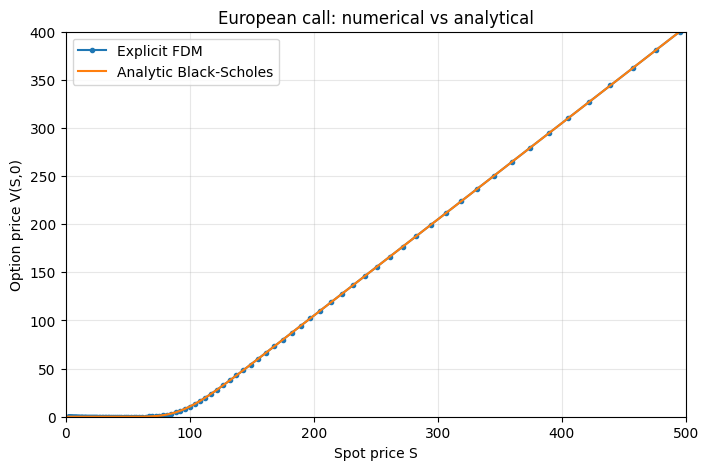

In [8]:
plot_explicit_vs_analytic(n_x=201, n_t=4001)

## The partial differential equation for this contract 

Since $V=V(S_1,S_2,t)$

$$\frac{\partial V}{\partial t} + rS_1 \frac{\partial V}{\partial S_1} + rS_2 \frac{\partial V}{\partial S_2} + \frac{1}{2}\sigma^2 S_1^2 \frac{\partial^2 V}{\partial S_1^2} + \frac{1}{2}\sigma^2 S_2^2 \frac{\partial^2 V}{\partial S_2^2} - rV = 0$$

By substituting

$$x = \log(S_1/K), \quad y = \log(S_2/K)$$

$$V = V(x, y, t).$$

$$V_t + \left( r - \frac{\sigma^2}{2} \right) V_x + \left( r - \frac{\sigma^2}{2} \right) V_y + \frac{\sigma^2}{2} V_{xx} + \frac{\sigma^2}{2} V_{yy} - rV = 0$$

The boundary conditions:

$$V(T, x, y) = K \max(e^x, e^y).$$

$$V(t, x_{\min}, y) \approx Ke^y, \quad V(t, x_{\max}, y) \approx Ke^{x_{\max}},$$$$V(t, x, y_{\min}) \approx Ke^x, \quad V(t, x, y_{\max}) \approx Ke^{y_{\max}}.$$

## Analytical solution

I couldnt derive the formula on my own, I used AI help for this part.

$$V(0) = S_1(0) \Phi(d_1) + S_2(0) \Phi(d_2)$$

$d_1 = \frac{\ln(S_1/S_2) + \frac{1}{2}\hat{\sigma}^2 T}{\hat{\sigma}\sqrt{T}}$

$d_2 = \frac{\ln(S_2/S_1) + \frac{1}{2}\hat{\sigma}^2 T}{\hat{\sigma}\sqrt{T}}$

$\hat{\sigma} = \sigma\sqrt{2}$

$\Phi$ standard normal distribution.

$$V(0) = 100 \cdot \Phi\left(\frac{\sigma\sqrt{T}}{\sqrt{2}}\right) + 100 \cdot \Phi\left(\frac{\sigma\sqrt{T}}{\sqrt{2}}\right) = 200 \cdot \Phi\left(\frac{\sigma\sqrt{T}}{\sqrt{2}}\right)$$

In [9]:
def analytic_max_equal_spots(S0, T, sigma):
    return 2.0 * S0 * norm.cdf(sigma * np.sqrt(T) / np.sqrt(2.0))

In [10]:
price_an = analytic_max_equal_spots(100.0, 1.0, 0.20)
print(price_an)

111.24629160182849


## Numerical scheme

In [11]:
K = 100.0
T = 1.0
R = 0.05
SIGMA = 0.20

x_min = -4
x_max = 4
y_min = -4
y_max = 4

n_x = 201
n_y = 201
n_t = 201

In [12]:
import math

def explicit_stability_report(x_min, x_max, y_min, y_max, T, sigma, n_x, n_y, n_t, safety_limit=0.5):
    dx = (x_max - x_min) / (n_x - 1)
    dy = (y_max - y_min) / (n_y - 1)
    dt = T / (n_t - 1)

    coeff = 0.5 * sigma**2 * (1.0 / dx**2 + 1.0 / dy**2)
    theta = coeff * dt

    dt_max = safety_limit / coeff
    n_t_min = math.ceil(T / dt_max) + 1

    print(f"dx = {dx:.6f}")
    print(f"dy = {dy:.6f}")
    print(f"dt = {dt:.6f}")
    print(f"theta = {theta:.6f} (<= 0.5?)")
    print(f"max allowed dt for safety_limit={safety_limit}: {dt_max:.6f}")
    print(f"recommended minimum n_t: {n_t_min}")

    if theta <= safety_limit:
        print("Stability check: OK")
    else:
        print("WARNING: likely unstable")

    return {
        "dx": dx,
        "dy": dy,
        "dt": dt,
        "theta": theta,
        "dt_max": dt_max,
        "n_t_min": n_t_min,
    }

In [13]:
report = explicit_stability_report(
    x_min, x_max, y_min, y_max, T, SIGMA, n_x, n_y, n_t
)

dx = 0.040000
dy = 0.040000
dt = 0.005000
theta = 0.125000 (<= 0.5?)
max allowed dt for safety_limit=0.5: 0.020000
recommended minimum n_t: 52
Stability check: OK


In [14]:
def boundary_max(grid, x_min, x_max, y_min, y_max, K, T):
    n_x, n_y, n_t = grid.shape

    x_values = np.linspace(x_min, x_max, n_x)
    y_values = np.linspace(y_min, y_max, n_y)

    # terminal condition at t = T
    for i, x in enumerate(x_values):
        for j, y in enumerate(y_values):
            grid[i, j, -1] = K * max(np.exp(x), np.exp(y))

    # boundaries for all times
    for n in range(n_t):
        # x = x_min and x = x_max
        for j, y in enumerate(y_values):
            grid[0,  j, n] = K * np.exp(y)
            grid[-1, j, n] = K * np.exp(x_max)

        # y = y_min and y = y_max
        for i, x in enumerate(x_values):
            grid[i, 0,  n] = K * np.exp(x)
            grid[i, -1, n] = K * np.exp(y_max)

    return grid

In [15]:
from tqdm import tqdm

def create_and_run_explicit_max(n_x, n_y, n_t):
    dx = (x_max - x_min) / (n_x - 1)
    dy = (y_max - y_min) / (n_y - 1)
    dt = T / (n_t - 1)

    grid = np.zeros((n_x, n_y, n_t))
    grid = boundary_max(grid, x_min, x_max, y_min, y_max, K, T)

    a = R - 0.5 * SIGMA**2
    b = 0.5 * SIGMA**2

    for n in tqdm(range(n_t - 1, 0, -1), desc="Time stepping"):
        for i in range(1, n_x - 1):
            for j in range(1, n_y - 1):
                vx = (grid[i + 1, j, n] - grid[i - 1, j, n]) / (2.0 * dx)
                vy = (grid[i, j + 1, n] - grid[i, j - 1, n]) / (2.0 * dy)

                vxx = (grid[i + 1, j, n] - 2.0 * grid[i, j, n] + grid[i - 1, j, n]) / dx**2
                vyy = (grid[i, j + 1, n] - 2.0 * grid[i, j, n] + grid[i, j - 1, n]) / dy**2

                grid[i, j, n - 1] = grid[i, j, n] + dt * (
                    a * vx
                    + a * vy
                    + b * vxx
                    + b * vyy
                    - R * grid[i, j, n]
                )

    return grid

In [16]:
def get_max_price_t0(grid, S1_0, S2_0, K):
    x_values = np.linspace(x_min, x_max, grid.shape[0])
    y_values = np.linspace(y_min, y_max, grid.shape[1])

    x0 = np.log(S1_0 / K)
    y0 = np.log(S2_0 / K)

    ix0 = np.argmin(np.abs(x_values - x0))
    iy0 = np.argmin(np.abs(y_values - y0))

    return grid[ix0, iy0, 0]

In [17]:
grid = create_and_run_explicit_max(n_x=n_x, n_y=n_y, n_t=n_t)

price_num = get_max_price_t0(grid, S1_0=100.0, S2_0=100.0, K=K)
price_an = analytic_max_equal_spots(100.0, 1.0, 0.20)

print("Numerical PDE price:", price_num)
print("Analytic price     :", price_an)
print("Absolute error     :", abs(price_num - price_an))

Time stepping: 100%|█████████████████████████████████████████████████████████████████| 200/200 [00:13<00:00, 14.92it/s]

Numerical PDE price: 111.23129001141662
Analytic price     : 111.24629160182849
Absolute error     : 0.015001590411870325


## Improving the run time by using vectors instead of for loops

In [18]:
def create_and_run_explicit_max_vectorized(n_x, n_y, n_t):
    dx = (x_max - x_min) / (n_x - 1)
    dy = (y_max - y_min) / (n_y - 1)
    dt = T / (n_t - 1)

    grid = np.zeros((n_x, n_y, n_t))
    grid = boundary_max(grid, x_min, x_max, y_min, y_max, K, T)

    a = R - 0.5 * SIGMA**2
    b = 0.5 * SIGMA**2

    for n in tqdm(range(n_t - 1, 0, -1), desc="Time stepping"):
        g = grid[:, :, n]

        vx = (g[2:, 1:-1] - g[:-2, 1:-1]) / (2.0 * dx)
        vy = (g[1:-1, 2:] - g[1:-1, :-2]) / (2.0 * dy)

        vxx = (g[2:, 1:-1] - 2.0 * g[1:-1, 1:-1] + g[:-2, 1:-1]) / dx**2
        vyy = (g[1:-1, 2:] - 2.0 * g[1:-1, 1:-1] + g[1:-1, :-2]) / dy**2

        grid[1:-1, 1:-1, n - 1] = g[1:-1, 1:-1] + dt * (
            a * vx
            + a * vy
            + b * vxx
            + b * vyy
            - R * g[1:-1, 1:-1]
        )

    return grid

In [19]:
grid = create_and_run_explicit_max_vectorized(n_x=n_x, n_y=n_y, n_t=n_t)

price_num = get_max_price_t0(grid, S1_0=100.0, S2_0=100.0, K=K)
price_an = analytic_max_equal_spots(100.0, 1.0, 0.20)

print("Numerical PDE price:", price_num)
print("Analytic price     :", price_an)
print("Absolute error     :", abs(price_num - price_an))

Time stepping: 100%|███████████████████████████████████████████████████████████████| 200/200 [00:00<00:00, 1305.00it/s]

Numerical PDE price: 111.23129001141662
Analytic price     : 111.24629160182849
Absolute error     : 0.015001590411870325


## Monte Carlo

In [20]:
def monte_carlo_bestof_two_assets(S1_0, S2_0, T, r, sigma, n_sim, seed=None):
    if seed is not None:
        np.random.seed(seed)

    Z1 = np.random.randn(n_sim)
    Z2 = np.random.randn(n_sim)

    S1_T = S1_0 * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z1)
    S2_T = S2_0 * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z2)

    payoffs = np.maximum(S1_T, S2_T)
    discounted_payoffs = np.exp(-r * T) * payoffs

    price_estimate = np.mean(discounted_payoffs)
    std_error = np.std(discounted_payoffs, ddof=1) / np.sqrt(n_sim)

    conf_low = price_estimate - 1.96 * std_error
    conf_high = price_estimate + 1.96 * std_error

    return price_estimate, std_error, conf_low, conf_high

In [21]:
price_mc, se_mc, ci_low, ci_high = monte_carlo_bestof_two_assets(
    S1_0=100.0,
    S2_0=100.0,
    T=T,
    r=R,
    sigma=SIGMA,
    n_sim=200000,
    seed=42
)

price_an

print("Monte Carlo price :", price_mc)
print("Std. error        :", se_mc)
print("95% CI            :", (ci_low, ci_high))
print("Analytic price    :", price_an)
print("Abs error         :", abs(price_mc - price_an))

Monte Carlo price : 111.25896185839767
Std. error        : 0.04179121376775127
95% CI            : (111.17705107941288, 111.34087263738246)
Analytic price    : 111.24629160182849
Abs error         : 0.012670256569180083
